# Exploring Financial Data using Nasdaq Data Link API

## Introduction
Our main goal is to extract financial data for a specific set of companies, with an emphasis on understanding their financial performance over time.
- To perform a detailed analysis of this financial data.
- Includes trends analysis and comparitive studies.

In [3]:
# Load API key from the environment, or a local config.py (not committed).
import os

api_key = os.getenv("NASDAQ_API_KEY")
if not api_key:
    try:
        import config
        api_key = getattr(config, "API_KEY", "")
    except ImportError:
        api_key = ""
if not api_key:
    raise ValueError(
        "Set NASDAQ_API_KEY or copy config.example.py to config.py (see project README)."
    )


In [19]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

api_url = 'https://data.nasdaq.com/api/v3/datatables/MER/F1.json'
parameters = {'api_key':api_key,
              'qopts.per_page':1000}
response = requests.get(api_url, params = parameters)
json_data = response.json()

In [20]:
columns = [col['name'] for col in json_data['datatable']['columns']]
data = json_data['datatable']['data']
df_metric = pd.DataFrame(data, columns = columns)
print(df_metric.head())


   compnumber    reportid  mapcode     amount  reportdate reporttype  \
0        2438  1868192544    -1802  10.481948  2011-06-30         Q2   
1        2438  1868216112    -1802   8.161754  2011-09-30         Q3   
2        2438  1885063456    -1802  10.788213  2012-06-30         Q2   
3        2438  1885087024    -1802   9.437545  2012-09-30         Q3   
4        2438  1901934112    -1802   8.755041  2013-06-30         Q2   

  auditorstatus currency consolidated          longname  ...  \
0             U      EUR         True  Deutsche Bank AG  ...   
1             U      EUR         True  Deutsche Bank AG  ...   
2             U      EUR         True  Deutsche Bank AG  ...   
3             U      EUR         True  Deutsche Bank AG  ...   
4             U      EUR         True  Deutsche Bank AG  ...   

                city statecode country zipcode     phonenumber  \
0  Frankfurt am Main      None     DEU   60325  (49) 69 910 00   
1  Frankfurt am Main      None     DEU   60325  (4

In [21]:
df_metric.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 32 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   compnumber     1000 non-null   int64  
 1   reportid       1000 non-null   int64  
 2   mapcode        1000 non-null   int64  
 3   amount         1000 non-null   float64
 4   reportdate     1000 non-null   object 
 5   reporttype     1000 non-null   object 
 6   auditorstatus  999 non-null    object 
 7   currency       1000 non-null   object 
 8   consolidated   1000 non-null   object 
 9   longname       1000 non-null   object 
 10  shortname      1000 non-null   object 
 11  status         1000 non-null   object 
 12  countrycode    1000 non-null   object 
 13  region         1000 non-null   object 
 14  cik            1000 non-null   int64  
 15  mic            1000 non-null   object 
 16  ticker         504 non-null    object 
 17  exchange       1000 non-null   object 
 18  address1 

## Filtering the DataFrame for Analysis


In [24]:
necessary_columns = ['indicator', 'country', 'longname', 'reportdate', 'reporttype', 'amount']
updated_data = df_metric[necessary_columns]
filtered_df = updated_data[updated_data['indicator'] == 'Accrued Expenses Turnover']
filtered_df.head()

,indicator,country,longname,reportdate,reporttype,amount
0,Accrued Expenses Turnover,DEU,Deutsche Bank AG,2011-06-30,Q2,10.481948
1,Accrued Expenses Turnover,DEU,Deutsche Bank AG,2011-09-30,Q3,8.161754
2,Accrued Expenses Turnover,DEU,Deutsche Bank AG,2012-06-30,Q2,10.788213
3,Accrued Expenses Turnover,DEU,Deutsche Bank AG,2012-09-30,Q3,9.437545
4,Accrued Expenses Turnover,DEU,Deutsche Bank AG,2013-06-30,Q2,8.755041


In [25]:
filtered_df.describe()

,amount
count,10.000000
mean,29.955639
std,32.228428
min,8.109493
25%,8.925667
50%,10.635081
75%,43.463150
max,107.533831


In [32]:
country_mapping = {
    'USA': 'United States of America',
    'DEU': 'Germany',
    'JPN': 'Japan',
    'CYM': 'Cayman Islands',
    'BHS': 'Bahamas',
    'IRL': 'Ireland'
   
}
def country_change(x):
    return country_mapping.get(x,x)
filtered_df['country_name'] = filtered_df['country'].apply(country_change)
column_mapping = {
    'longname': 'company_name',
    'reportdate': 'report_date',
    'reporttype': 'report_type'
}
filtered_df.rename(columns = column_mapping, inplace = True)
print(filtered_df['country_name'].value_counts())

country_name
Germany    6
Bahamas    4
Name: count, dtype: int64


/tmp/ipykernel_41/1083565272.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['country_name'] = filtered_df['country'].apply(country_change)
/tmp/ipykernel_41/1083565272.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df.rename(columns = column_mapping, inplace = True)


In [33]:
filtered_df.head()

,indicator,country,company_name,report_date,report_type,amount,country_name
0,Accrued Expenses Turnover,DEU,Deutsche Bank AG,2011-06-30,Q2,10.481948,Germany
1,Accrued Expenses Turnover,DEU,Deutsche Bank AG,2011-09-30,Q3,8.161754,Germany
2,Accrued Expenses Turnover,DEU,Deutsche Bank AG,2012-06-30,Q2,10.788213,Germany
3,Accrued Expenses Turnover,DEU,Deutsche Bank AG,2012-09-30,Q3,9.437545,Germany
4,Accrued Expenses Turnover,DEU,Deutsche Bank AG,2013-06-30,Q2,8.755041,Germany


In [34]:
# Convert 'report_date' to datetime and filter for 2010-2015
updated_df = filtered_df.copy()
updated_df['report_date'] = pd.to_datetime(updated_df['report_date'])
updated_df = updated_df[(updated_df['report_date'].dt.year >= 2010) & (updated_df['report_date'].dt.year <= 2015)]

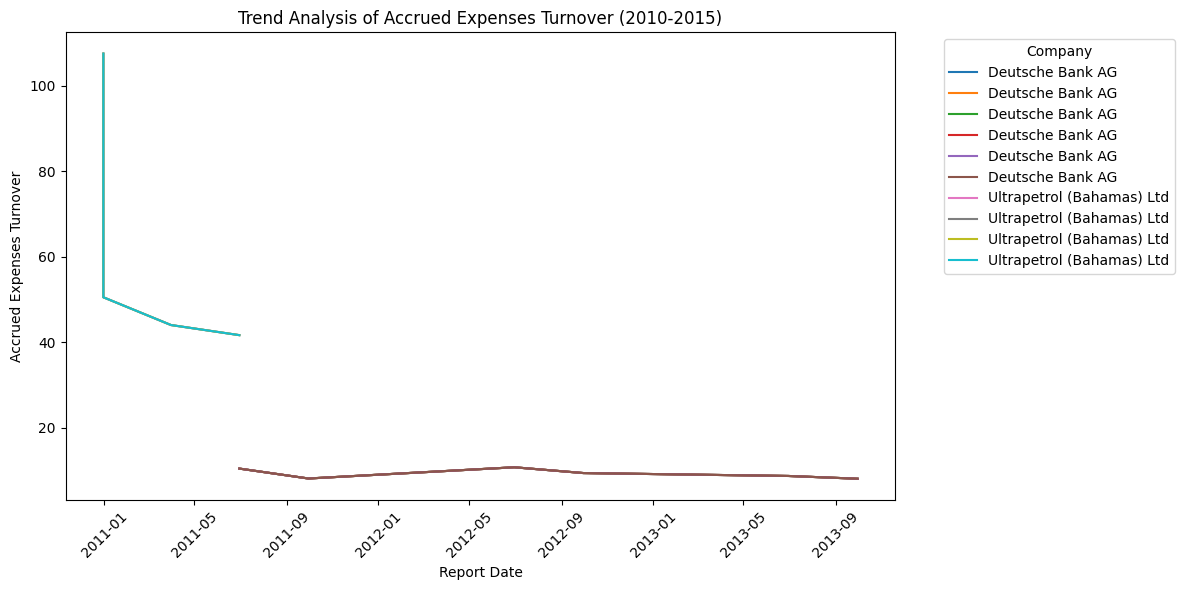

In [35]:
import matplotlib.pyplot as plt

relevant_data = updated_df[['company_name', 'report_date', 'amount']].copy()

plt.figure(figsize=(12, 6))
for company in relevant_data['company_name']:
    company_data = relevant_data[relevant_data['company_name'] == company]
    plt.plot(company_data['report_date'], company_data['amount'], label = company)

plt.title('Trend Analysis of Accrued Expenses Turnover (2010-2015)')
plt.xlabel('Report Date')
plt.ylabel('Accrued Expenses Turnover')
plt.xticks(rotation=45)
plt.legend(title='Company', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

    

## Geographical Region Analysis

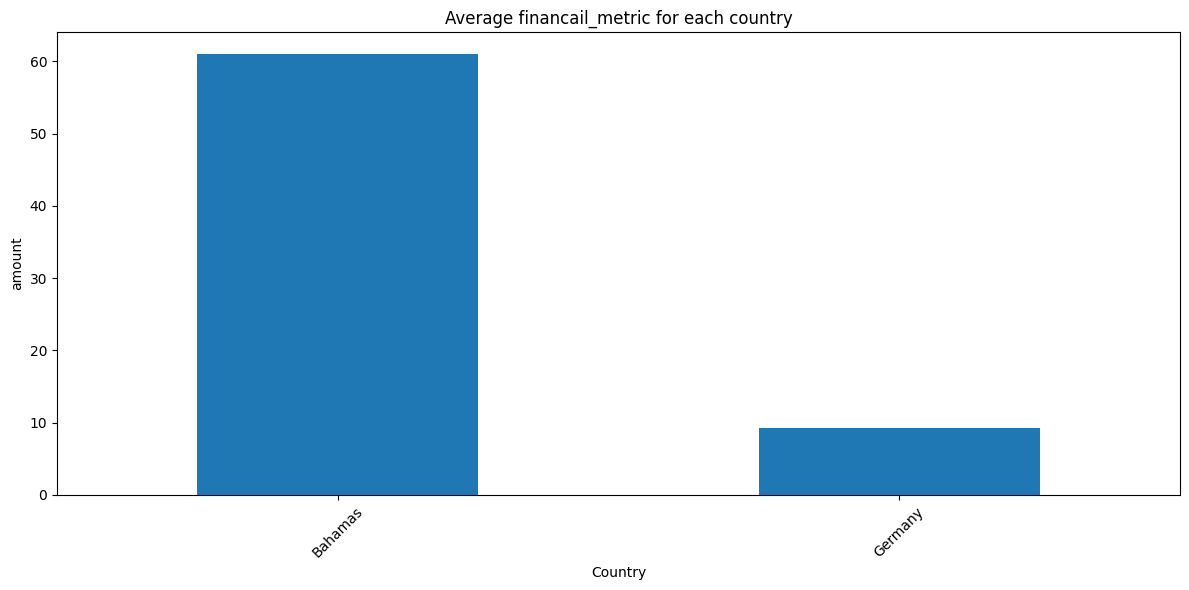

In [37]:
# Grouping data by country and calculating the average of the 'amount'
country_avg = updated_df.groupby('country_name')['amount'].mean()
plt.figure(figsize = (12,6))
country_avg.plot(kind='bar')
plt.title('Average financail_metric for each country')
plt.xlabel('Country')
plt.ylabel('amount')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()